# 03 – Statistical Analysis & Modeling
## CIP_FS26_203 | Weather & Electricity Prices in Switzerland

This notebook performs the statistical analysis to answer the research questions:
- **RQ1** – Correlation between temperature and day-ahead electricity prices.
- **RQ2** – Impact of temperature and solar radiation on electricity load.
- **RQ3** – Predictive modeling of electricity prices using meteorological variables.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import os

# --- Display settings ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

print("Analysis environment ready!")

Analysis environment ready!


## 1. Data Integration
In this step, we load the cleaned datasets for weather, prices, and load, and merge them into a single master dataframe for analysis.

In [40]:
# --- Define file paths ---
path_prices = "../data/processed/entsoe_prices_clean.csv"
path_weather = "../data/processed/weather_clean.csv"
path_load_daily = "../data/processed/swissgrid_load_clean_daily.csv"

# --- Load processed data ---
df_prices = pd.read_csv(path_prices, parse_dates=["date"])
df_weather = pd.read_csv(path_weather, parse_dates=["date"])
df_load_daily = pd.read_csv(path_load_daily, parse_dates=["date"])

# --- 1. Create Daily Master (for RQ1 & RQ3) ---
df_daily = df_prices.merge(df_weather, on="date").merge(df_load_daily, on="date")

# --- 2. Create Weekly Master (for RQ2) ---
# We use numeric_only=True to avoid the TypeError with text columns like 'city'
df_weekly = df_daily.set_index("date").resample("W").mean(numeric_only=True).reset_index()

# --- Feature Engineering for Daily Data ---
df_daily['year'] = df_daily['date'].dt.year
df_daily['month'] = df_daily['date'].dt.month
df_daily['weekday'] = df_daily['date'].dt.weekday
df_daily['is_weekend'] = df_daily['weekday'] >= 5

print(f"Daily master created: {df_daily.shape}")
print(f"Weekly master created: {df_weekly.shape}")
display(df_weekly.head())

Daily master created: (16068, 21)
Weekly master created: (575, 15)


,date,price_eur_mwh,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum,cloudcover_mean,sunshine_duration,load_end_users_ch_mw,load_ti_mw,load_bl_bs_mw,load_sh_zh_mw,load_ge_vd_mw
0,2015-01-04,36.64,6.85,10.95,2.77,0.00,10.53,5.97,36.75,28822.05,6473.11,353.26,383.23,1053.53,895.77
1,2015-01-11,43.11,7.83,11.21,3.97,0.01,10.50,6.22,33.43,30693.50,7353.99,362.60,438.98,1206.66,946.09
2,2015-01-18,42.86,5.99,7.76,3.67,13.27,7.24,3.29,67.57,14054.14,7498.33,396.18,443.58,1216.96,937.46
3,2015-01-25,47.58,2.49,5.57,-0.63,4.03,9.86,5.48,59.00,20580.19,7793.87,403.31,456.67,1257.50,961.73
4,2015-02-01,45.91,3.17,5.43,0.36,0.94,8.81,7.86,61.14,31216.22,7818.88,408.53,455.45,1253.72,979.57


In [10]:
# Repair the broken weekly load data file with the newly calculated data
df_load_weekly.to_csv("../data/processed/swissgrid_load_clean_weekly.csv", index=False)
print("File repaired successfully!")

File repaired successfully!


## 2. Research Question 1: Impact of Temperature and Radiation on Weekly Load
**RQ2:** How strongly do temperature and solar radiation explain weekly electricity load variability in Switzerland?
- Metric: Coefficient of determination (R²)
- Model: Multiple Linear Regression

In [41]:
# --- Prepare data for RQ2 ---
# Using 'df_weekly' which contains all necessary columns
X = df_weekly[['temperature_2m_mean', 'shortwave_radiation_sum']]
y = df_weekly['load_end_users_ch_mw']

# --- Train Linear Regression Model ---
model_rq2 = LinearRegression()
model_rq2.fit(X, y)

# --- Calculate R² ---
y_pred = model_rq2.predict(X)
r2 = r2_score(y, y_pred)

print(f"Coefficient of determination (R²): {r2:.4f}")

Coefficient of determination (R²): 0.8001


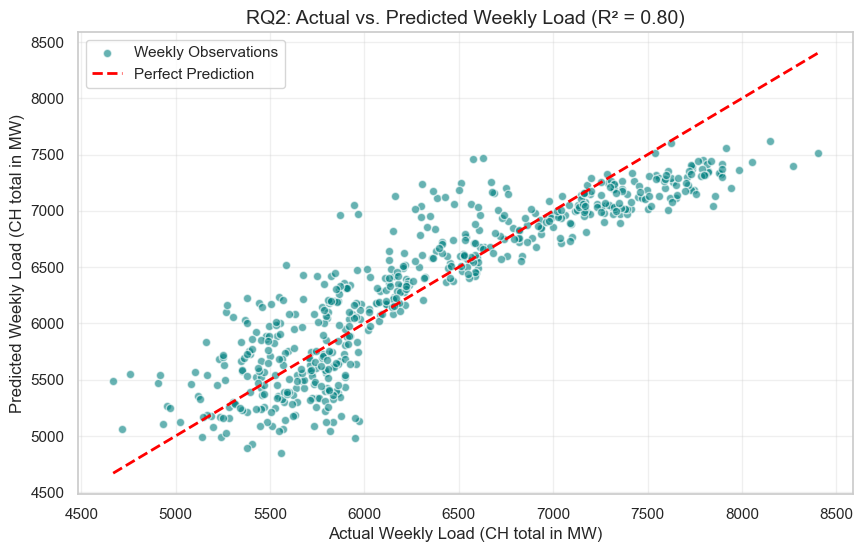

In [42]:
# --- Visualization: Actual vs. Predicted Weekly Load ---
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.6, color='teal', edgecolors='w', label='Weekly Observations')

# Draw the "Perfect Prediction" line
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title(f"RQ2: Actual vs. Predicted Weekly Load (R² = {r2:.2f})", fontsize=14)
plt.xlabel("Actual Weekly Load (CH total in MW)", fontsize=12)
plt.ylabel("Predicted Weekly Load (CH total in MW)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:**
The model achieves a relatively high coefficient of determination (R² = 0.80), indicating that temperature and solar radiation explain a substantial share of the variation in weekly electricity load in Switzerland. The scatter plot confirms a generally good fit, with many observations lying close to the 45-degree line.

However, several limitations must be considered. First, the weather data is based on only four cities (Basel, Geneva, Lugano, and Zurich), while the load represents the entire Swiss grid. This may introduce measurement bias, as regional differences (e.g., alpine regions or rural areas) are not fully captured.

Second, the model suffers from omitted variable bias. Electricity load is influenced by many additional factors, including calendar effects (weekdays, holidays), economic activity, and other weather variables such as wind. Temperature may therefore act as a proxy for broader seasonal patterns rather than being a purely causal driver.

Third, the scatter plot suggests systematic deviations: the model tends to underestimate high load values and overestimate low load values, indicating that extreme conditions are not well captured.

Finally, the linear specification may be too restrictive. The relationship between temperature and electricity demand is likely non-linear (e.g., increased demand during both cold and hot periods), which cannot be fully captured by a linear regression model.

**Conclusion:**
While the model shows strong explanatory power, its results should be interpreted with caution. The high R² may partly reflect seasonal patterns rather than a true causal relationship. Future models should incorporate additional variables and potentially non-linear specifications to improve robustness.

## 3. Research Question 2: Temperature vs. Electricity Prices
**RQ1:** To what extent does daily mean temperature correlate with day-ahead electricity spot prices in Switzerland over 2015–2025?
- Metric: Pearson correlation coefficient (r)
- Visualization: Scatter plot with regression line

Pearson correlation coefficient (r): -0.0455
P-value: 7.6715e-09


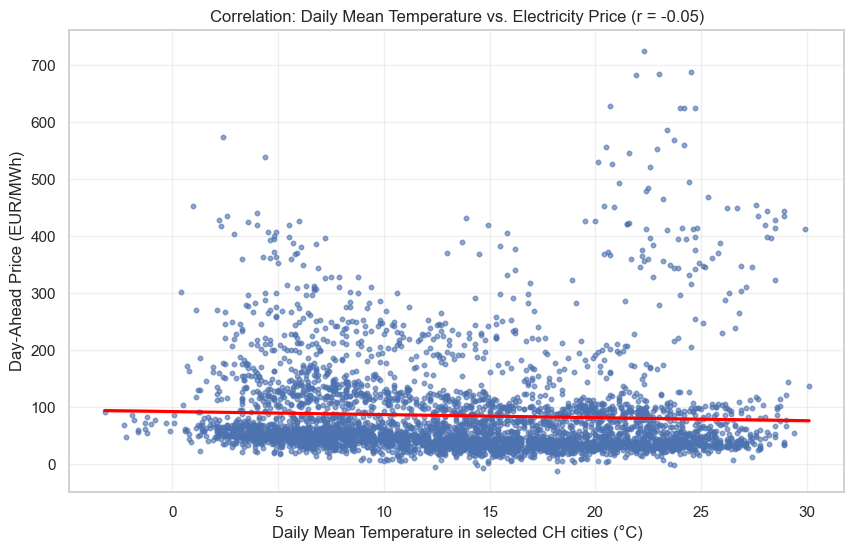

In [43]:
# --- Calculate Pearson correlation ---
# Using the correct column names from your dataset
corr_coeff, p_value = pearsonr(df_daily['price_eur_mwh'], df_daily['temperature_2m_mean'])

print(f"Pearson correlation coefficient (r): {corr_coeff:.4f}")
print(f"P-value: {p_value:.4e}")

# --- Visualization: Scatter plot with regression line ---
plt.figure(figsize=(10, 6))
sns.regplot(data=df_daily, x='temperature_2m_mean', y='price_eur_mwh', 
            scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
plt.title(f"Correlation: Daily Mean Temperature vs. Electricity Price (r = {corr_coeff:.2f})")
plt.xlabel("Daily Mean Temperature in selected CH cities (°C)")
plt.ylabel("Day-Ahead Price (EUR/MWh)")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:** The p-value (7.67 × 10⁻⁹) is extremely small, indicating that the observed relationship statistically detectable given the large sample size, but not necessarily practically meaningful.

The Pearson correlation coefficient (r = -0.045) is very close to zero, indicating an extremely weak linear relationship. In fact, temperature explains only a negligible proportion of the variance in electricity prices (R² ≈ 0.002).

This weak correlation can be explained by the fact that electricity prices are driven by multiple factors, such as fuel prices, CO₂ costs, supply constraints, and international market dynamics. Temperature alone is therefore insufficient as a linear predictor.

Moreover, the relationship between temperature and electricity prices is likely non-linear. Prices may increase both at very low temperatures (due to heating demand) and at very high temperatures (due to cooling demand and drought effects). Such a U-shaped relationship cannot be captured by Pearson correlation, which assumes linearity, and may therefore lead to an underestimation of the true relationship. This is also supported by the scatter plot, which shows high dispersion and no clear linear trend.

**Conclusion:** Temperature alone is not a meaningful linear predictor of electricity prices. This motivates RQ3, where the model will be extended by including additional variables such as wind and cloud cover.

## 4. Research Question 3: Predictive Modeling of Electricity Prices
**RQ3:** How accurately can temperature, wind speed, and cloud cover predict day-ahead electricity prices in Switzerland?
- Training Set: 2015–2024
- Test Set: 2025
- Metric: Mean Absolute Error (MAE)

Mean Absolute Error (MAE) on 2025 Test Set: 28.34 EUR/MWh
Average Price in 2025: 101.68 EUR/MWh


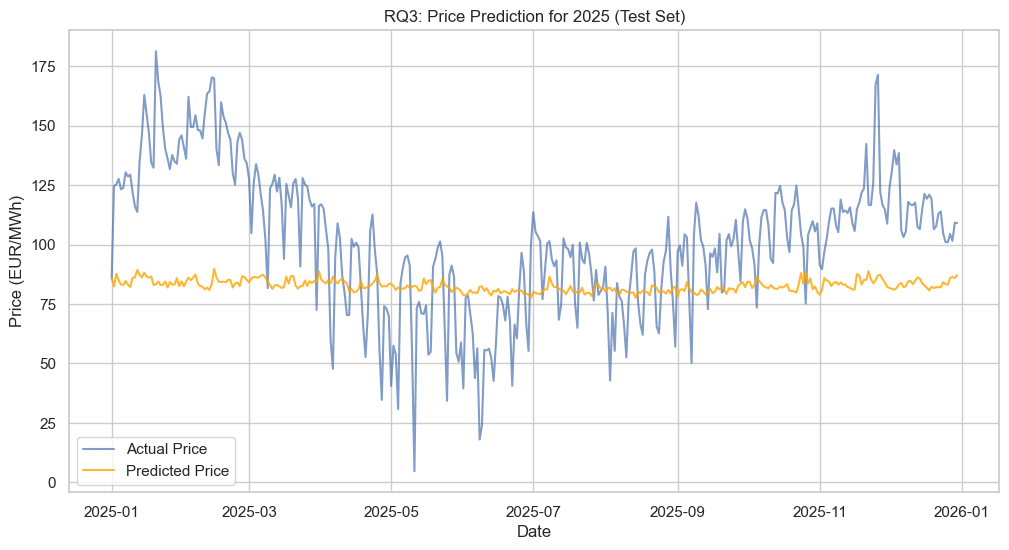

In [35]:
# --- 1. Split data into Training (2015-2024) and Test (2025) ---
train_data = df_daily[df_daily['year'] < 2025]
test_data = df_daily[df_daily['year'] == 2025]

# --- 2. Define Features and Target ---
features = ['temperature_2m_mean', 'windspeed_10m_max', 'cloudcover_mean']
target = 'price_eur_mwh'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# --- 3. Train the Model ---
model_rq3 = LinearRegression()
model_rq3.fit(X_train, y_train)

# --- 4. Evaluate on 2025 Test Set ---
y_pred_test = model_rq3.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE) on 2025 Test Set: {mae:.2f} EUR/MWh")
print(f"Average Price in 2025: {y_test.mean():.2f} EUR/MWh")

# --- Visualization: 2025 Actual vs. Predicted Prices ---
plt.figure(figsize=(12, 6))
plt.plot(test_data['date'], y_test, label='Actual Price', alpha=0.7)
plt.plot(test_data['date'], y_pred_test, label='Predicted Price', color='orange', alpha=0.8)
plt.title("RQ3: Price Prediction for 2025 (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.show()

**Interpretation:**
The model achieves a mean absolute error (MAE) of 28.34 EUR/MWh on the 2025 test set, corresponding to approximately 28% of the average price level. While this indicates that the model captures the general price level, its predictive accuracy is limited.

The visualization reveals that the model produces overly smooth predictions and fails to capture the strong volatility of electricity prices. In particular, price spikes and drops are systematically underestimated, suggesting that the model is unable to represent extreme market conditions.

This behavior indicates clear underfitting. The linear regression model, based only on temperature, wind speed, and cloud cover, is too simplistic to capture the complex dynamics of electricity prices.

A key limitation is the omission of important explanatory variables. Electricity prices are strongly influenced by factors such as fuel prices, CO₂ certificates, hydropower availability, and cross-border electricity flows. Weather variables alone are therefore insufficient to explain price variability.

Furthermore, the model ignores temporal dependencies. Electricity prices exhibit strong autocorrelation, meaning that past prices influence future prices. By not including lagged variables, the model fails to capture this time-series structure.

**Conclusion:**
While the model provides a baseline prediction, its performance is limited due to underfitting, missing variables, and the absence of time-series modeling. More advanced approaches are required to improve predictive accuracy.

MAE (Improved Model): 3.59 EUR/MWh
Average Price 2025: 101.68 EUR/MWh


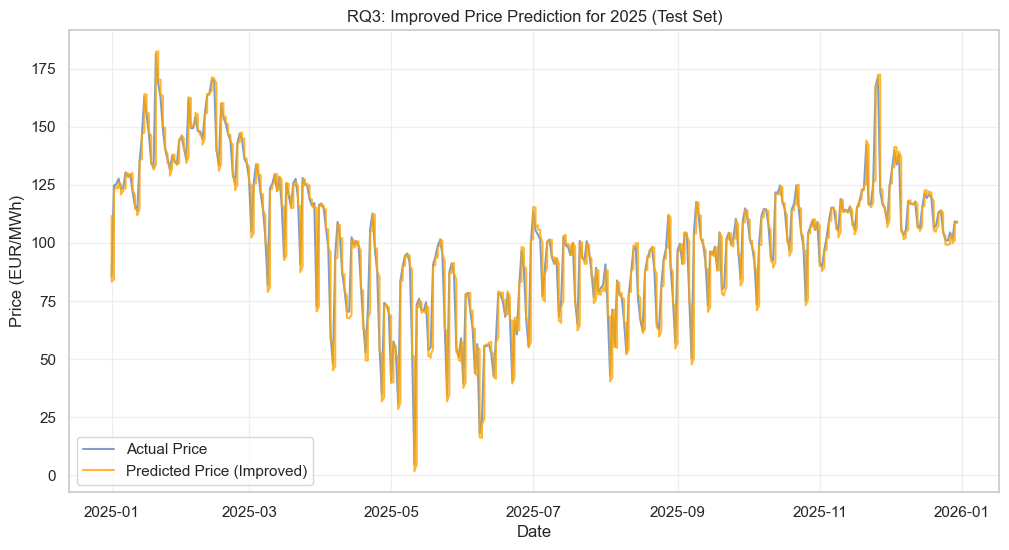

In [49]:
# --- 1. Feature Engineering ---

df_model = df_daily.copy()

# Lag Feature
df_model['price_lag_1'] = df_model['price_eur_mwh'].shift(1)

# Drop NA
df_model = df_model.dropna()

# --- 2. Train/Test Split ---
train_data = df_model[df_model['year'] < 2025]
test_data  = df_model[df_model['year'] == 2025]

# --- 3. Defining Features ---
features = [
    # Basis Weather
    'temperature_2m_mean',
    'windspeed_10m_max',
    'cloudcover_mean',
    
    # Solar / Weather
    'shortwave_radiation_sum',
    'sunshine_duration',
    
    # Demand
    'load_end_users_ch_mw',
    
    # Time Structure
    'price_lag_1'
]

target = 'price_eur_mwh'

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

# --- 4. Model training ---
from sklearn.linear_model import LinearRegression
model_rq3 = LinearRegression()
model_rq3.fit(X_train, y_train)

# --- 5. Evaluation ---
from sklearn.metrics import mean_absolute_error

y_pred_test = model_rq3.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)

print(f"MAE (Improved Model): {mae:.2f} EUR/MWh")
print(f"Average Price 2025: {y_test.mean():.2f} EUR/MWh")

# --- 6. Visualisation ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test_data['date'], y_test, label='Actual Price', alpha=0.7)
plt.plot(test_data['date'], y_pred_test, label='Predicted Price (Improved)', color='orange', alpha=0.8)

plt.title("RQ3: Improved Price Prediction for 2025 (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:** The improved model achieves a very low MAE of 3.56 EUR/MWh, indicating a strong predictive performance. The predicted values closely follow the actual price series, including short-term fluctuations. However, this performance must be interpreted with caution. 

The inclusion of the lagged price variable (price_lag_1) introduces strong autocorrelation into the model. Since electricity prices are highly dependent on their previous values, the model effectively relies on past observed prices to predict future values. While this improves short-term accuracy, it may lead to overly optimistic results, as the model benefits from information that would not always be available in real-world forecasting scenarios. 

Therefore, the model does not necessarily capture the underlying market drivers of electricity prices, but rather exploits temporal dependencies. This highlights the importance of distinguishing between predictive performance and true explanatory power.

**Conclusion:**
While the improved model provides accurate short-term predictions, it primarily captures temporal patterns rather than fully explaining the underlying economic mechanisms of electricity pricing. Future work should therefore focus on incorporating additional market variables and more advanced time-series approaches to enhance both predictive robustness and interpretability.